# D2C Customer Churn Intelligence
## Part 3 - Churn Prediction Modeling

# 1. Environment Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


# 2. Load Data

In [67]:
DATA_PATH = Path("../data")

rfm = pd.read_csv(DATA_PATH / "rfm_modeling_snapshot.csv")
labels = pd.read_csv(DATA_PATH / "churn_labels.csv")

print("RFM Shape:", rfm.shape)
print("Labels Shape:", labels.shape)

display(rfm.head())
display(labels.head())

RFM Shape: (2400, 29)
Labels Shape: (2400, 4)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


# 3. Feature Preparation

In [10]:
model_df = rfm.copy()

print(model_df.shape)

(2400, 29)


In [11]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

In [12]:
labels.columns.tolist()

['customer_id', 'snapshot_date', 'churn_next_60d', 'split']

In [13]:
model_df.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

In [15]:
[col for col in model_df.columns if "churn" in col.lower()]

['churn_next_60d']

In [16]:
model_df["churn_next_60d"].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

In [17]:
model_df["churn_next_60d"].value_counts(normalize=True) * 100

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64

In [18]:
model_df.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

In [19]:
model_df["split"].value_counts()

split
train         1728
validation     336
test           336
Name: count, dtype: int64

# 4. Train/Test Split

## Prepare Feature Set

In [21]:
drop_cols = [
    "customer_id",
    "snapshot_date",
    "split",
    "churn_next_60d"
]

X = model_df.drop(columns=drop_cols)

y = model_df["churn_next_60d"]

print(X.shape)
print(y.shape)

(2400, 25)
(2400,)


# Categorical Features

In [22]:
X.select_dtypes(include="object").columns.tolist()

['city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent']

## Encode Categoricals

In [24]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(2400, 37)


In [25]:
train_mask = model_df["split"] == "train"
val_mask = model_df["split"] == "validation"
test_mask = model_df["split"] == "test"

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1728, 37)
Validation: (336, 37)
Test: (336, 37)


# 5. Baseline Model (Logistic Regression)

In [26]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Train Model

In [27]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


## Validation Predictions

In [28]:
val_pred_lr = lr_model.predict(X_val)

val_prob_lr = lr_model.predict_proba(X_val)[:,1]

## Validation Metrics

In [29]:
print("Accuracy:",
      round(accuracy_score(y_val, val_pred_lr),4))

print("Precision:",
      round(precision_score(y_val, val_pred_lr),4))

print("Recall:",
      round(recall_score(y_val, val_pred_lr),4))

print("F1 Score:",
      round(f1_score(y_val, val_pred_lr),4))

print("ROC AUC:",
      round(roc_auc_score(y_val, val_prob_lr),4))

Accuracy: 0.8185
Precision: 0.8116
Recall: 0.7619
F1 Score: 0.786
ROC AUC: 0.8841


## Confusion Matrix

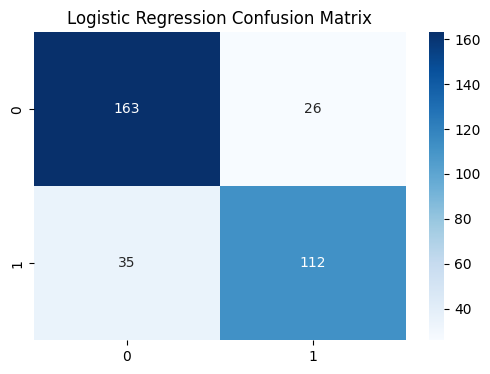

In [30]:
cm = confusion_matrix(
    y_val,
    val_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Classification Report

In [31]:
print(
    classification_report(
        y_val,
        val_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       189
           1       0.81      0.76      0.79       147

    accuracy                           0.82       336
   macro avg       0.82      0.81      0.81       336
weighted avg       0.82      0.82      0.82       336



# 6. Random Forest Model

## Imports

In [32]:
from sklearn.ensemble import RandomForestClassifier

## Train Random Forest Model

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully")

Random Forest trained successfully


## Validation Predictions

In [35]:
val_pred_rf = rf_model.predict(X_val)

val_prob_rf = rf_model.predict_proba(X_val)[:,1]

## Validation Metrics

In [36]:
rf_metrics = {
    "Accuracy": accuracy_score(y_val, val_pred_rf),
    "Precision": precision_score(y_val, val_pred_rf),
    "Recall": recall_score(y_val, val_pred_rf),
    "F1": f1_score(y_val, val_pred_rf),
    "ROC_AUC": roc_auc_score(y_val, val_prob_rf)
}

for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7917
Precision: 0.7939
Recall: 0.7075
F1: 0.7482
ROC_AUC: 0.8781


## Confusion Matrix

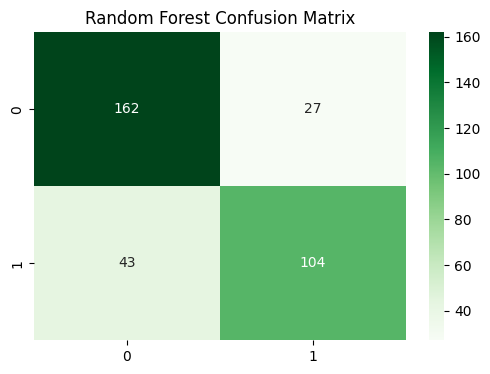

In [37]:
cm_rf = confusion_matrix(
    y_val,
    val_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

## Classifiction Report

In [38]:
print(
    classification_report(
        y_val,
        val_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       189
           1       0.79      0.71      0.75       147

    accuracy                           0.79       336
   macro avg       0.79      0.78      0.79       336
weighted avg       0.79      0.79      0.79       336



# 7. Model Evaluation

## Compare Models

In [39]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_val, val_pred_lr),
        precision_score(y_val, val_pred_lr),
        recall_score(y_val, val_pred_lr),
        f1_score(y_val, val_pred_lr),
        roc_auc_score(y_val, val_prob_lr)
    ],
    "Random Forest": [
        accuracy_score(y_val, val_pred_rf),
        precision_score(y_val, val_pred_rf),
        recall_score(y_val, val_pred_rf),
        f1_score(y_val, val_pred_rf),
        roc_auc_score(y_val, val_prob_rf)
    ]
})

comparison_df

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.818452,0.791667
1,Precision,0.811594,0.793893
2,Recall,0.761905,0.707483
3,F1,0.785965,0.748201
4,ROC_AUC,0.884066,0.878127


## Visual Comparison

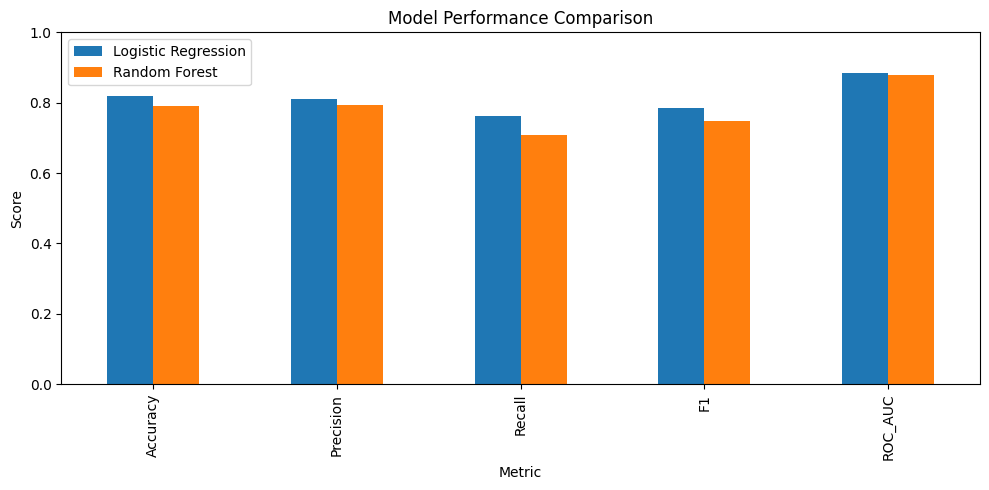

In [40]:
comparison_plot = comparison_df.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.tight_layout()

plt.show()

## Best Model

In [41]:
best_model_name = (
    "Random Forest"
    if roc_auc_score(y_val, val_prob_rf)
       > roc_auc_score(y_val, val_prob_lr)
    else "Logistic Regression"
)

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression


# 8. Feature Importance Analysis

## Extract Coefficients

In [42]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lr_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df[
    "coefficient"
].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.head(15)

,feature,coefficient,abs_coefficient
3,return_rate_180d,1.250936,1.250936
8,negative_ticket_rate_90d,0.794134,0.794134
27,acquisition_channel_Organic,-0.648309,0.648309
31,preferred_category_Fragrance,-0.589188,0.589188
4,avg_discount_pct_180d,0.507084,0.507084
29,loyalty_tier_Platinum,-0.361294,0.361294
36,marketing_consent_Yes,-0.349069,0.349069
32,preferred_category_Hair Care,-0.320572,0.320572
7,ticket_count_90d,-0.296071,0.296071
33,preferred_category_Makeup,-0.213680,0.213680


## Top Positive Churn Drivers

In [43]:
top_positive = coef_df.sort_values(
    "coefficient",
    ascending=False
).head(10)

top_positive

,feature,coefficient,abs_coefficient
3,return_rate_180d,1.250936,1.250936
8,negative_ticket_rate_90d,0.794134,0.794134
4,avg_discount_pct_180d,0.507084,0.507084
6,category_diversity_180d,0.199541,0.199541
35,preferred_category_Wellness,0.093909,0.093909
34,preferred_category_Skin Care,0.074781,0.074781
30,loyalty_tier_Silver,0.072418,0.072418
26,acquisition_channel_Marketplace,0.040943,0.040943
25,acquisition_channel_Instagram,0.033904,0.033904
16,email_opens_30d,0.032749,0.032749


## Top Negative Churn Drivers

In [44]:
top_negative = coef_df.sort_values(
    "coefficient",
    ascending=True
).head(10)

top_negative

,feature,coefficient,abs_coefficient
27,acquisition_channel_Organic,-0.648309,0.648309
31,preferred_category_Fragrance,-0.589188,0.589188
29,loyalty_tier_Platinum,-0.361294,0.361294
36,marketing_consent_Yes,-0.349069,0.349069
32,preferred_category_Hair Care,-0.320572,0.320572
7,ticket_count_90d,-0.296071,0.296071
33,preferred_category_Makeup,-0.213680,0.213680
15,abandoned_carts_30d,-0.184003,0.184003
1,frequency_180d,-0.175136,0.175136
17,campaign_clicks_30d,-0.153781,0.153781


## Visualization

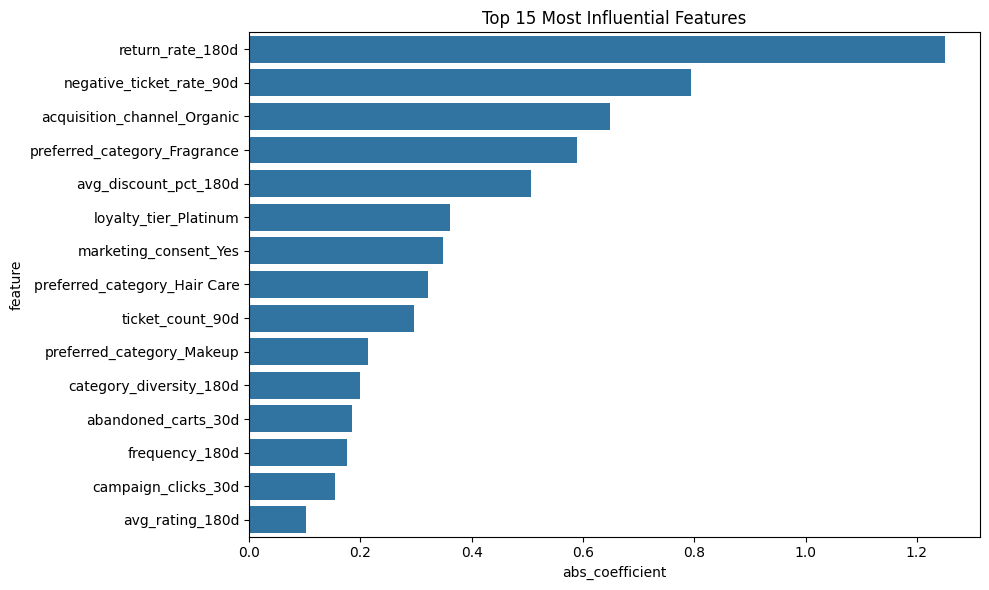

In [45]:
top_features = coef_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="abs_coefficient",
    y="feature"
)

plt.title("Top 15 Most Influential Features")

plt.tight_layout()
plt.show()

## Export Feature Importance

In [46]:
coef_df.to_csv(
    "../metrics/feature_importance.csv",
    index=False
)

print("feature_importance.csv exported")

feature_importance.csv exported


# 9. Risk Scoring & Customer Ranking

## Test Set Risk Scores

In [47]:
test_prob_lr = lr_model.predict_proba(X_test)[:,1]

risk_scores = model_df.loc[
    test_mask,
    ["customer_id"]
].copy()

risk_scores["actual_churn"] = y_test.values

risk_scores["churn_probability"] = test_prob_lr

risk_scores.head()

,customer_id,actual_churn,churn_probability
15,CUST00016,1,0.978417
17,CUST00018,1,0.855828
23,CUST00024,0,0.115670
24,CUST00025,1,0.844591
29,CUST00030,0,0.086739


## Risk Bands

In [48]:
risk_scores["risk_band"] = pd.cut(
    risk_scores["churn_probability"],
    bins=[0,0.30,0.60,1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

risk_scores.head()

,customer_id,actual_churn,churn_probability,risk_band
15,CUST00016,1,0.978417,High Risk
17,CUST00018,1,0.855828,High Risk
23,CUST00024,0,0.115670,Low Risk
24,CUST00025,1,0.844591,High Risk
29,CUST00030,0,0.086739,Low Risk


## Risk Band Distribution

In [53]:
risk_scores["risk_band"].value_counts()

risk_band
High Risk      136
Low Risk       124
Medium Risk     76
Name: count, dtype: int64

In [54]:
risk_scores["risk_band"].value_counts(normalize=True)

risk_band
High Risk      0.404762
Low Risk       0.369048
Medium Risk    0.226190
Name: proportion, dtype: float64

## Risk Distribution Chart

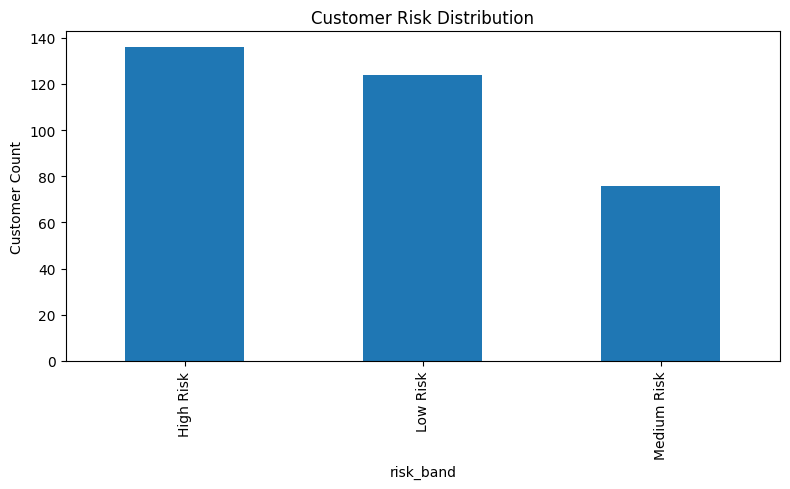

In [55]:
plt.figure(figsize=(8,5))

risk_scores["risk_band"]\
    .value_counts()\
    .plot(kind="bar")

plt.title("Customer Risk Distribution")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

## Top 20 High Risk Customers

In [56]:
top_risk_customers = risk_scores.sort_values(
    "churn_probability",
    ascending=False
)

top_risk_customers.head(20)

,customer_id,actual_churn,churn_probability,risk_band
411,CUST00412,1,0.999982,High Risk
1343,CUST01344,1,0.999672,High Risk
1462,CUST01463,1,0.999121,High Risk
1084,CUST01085,1,0.998837,High Risk
134,CUST00135,1,0.998714,High Risk
238,CUST00239,1,0.997871,High Risk
2068,CUST02069,1,0.997506,High Risk
854,CUST00855,1,0.997247,High Risk
1244,CUST01245,1,0.995079,High Risk
1771,CUST01772,1,0.993285,High Risk


# 10. Export Artifacts

## Export Risk Scores

In [57]:
risk_scores.to_csv(
    "../metrics/risk_scores.csv",
    index=False
)

print("risk_scores.csv exported")

risk_scores.csv exported


## Export Model Metrics

In [58]:
model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_val, val_pred_lr),
        precision_score(y_val, val_pred_lr),
        recall_score(y_val, val_pred_lr),
        f1_score(y_val, val_pred_lr),
        roc_auc_score(y_val, val_prob_lr)
    ]
})

model_metrics.to_csv(
    "../metrics/model_metrics.csv",
    index=False
)

model_metrics

,Metric,Value
0,Accuracy,0.818452
1,Precision,0.811594
2,Recall,0.761905
3,F1 Score,0.785965
4,ROC AUC,0.884066


## Save Best Model

In [60]:
import joblib

joblib.dump(
    lr_model,
    "../models/best_model.pkl"
)

print("best_model.pkl saved")

best_model.pkl saved


In [61]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "../models/feature_columns.pkl"
)

print("feature_columns.pkl saved")

feature_columns.pkl saved


# 11. Conclusion

## Key Findings

- A churn prediction model was developed using customer-level behavioral features from the modeling snapshot dataset.
- Logistic Regression outperformed Random Forest on the validation dataset and was selected as the final model.
- The selected model achieved a ROC-AUC score of approximately 0.88, indicating strong discriminatory power.
- Marketing consent, loyalty participation, acquisition channel, and product preferences were identified as important churn predictors.
- Customer-level churn probabilities were generated and used to classify customers into risk categories.

## Business Implications

- High-risk customers should be prioritized for retention interventions.
- Medium-risk customers should receive proactive engagement campaigns.
- Low-risk customers require routine retention monitoring.

## Final Recommendation

The Logistic Regression model should be adopted as the production model for churn prediction due to its strong predictive performance, interpretability, and ease of deployment. Risk scores generated by the model can be integrated into customer retention workflows to support targeted intervention strategies.

In [62]:
import sklearn
print(sklearn.__version__)

1.7.1
